In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mnso
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso

In [139]:
data = pd.read_csv('second_hand_cars.csv')
data.head()

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


In [140]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

In [141]:
data.drop_duplicates(inplace = True)

In [142]:
columns = ['Company Name', 'Car Name', 'Variant', 'Fuel Type', 'Tyre Condition',
       'Make Year', 'Owner Type', 'Registration Number', 'Mileage', 'Price',
       'Transmission Type', 'Body Color', 'Service Record', 'Insurance',
       'Registration Certificate', 'Accessories']
for column in columns:
    print(f"{column} value count:\n{data[column].value_counts()}")

Company Name value count:
Company Name
Nissan           270
Kia              266
Honda            257
Toyota           250
Chevrolet        249
Ford             249
Volkswagen       248
Maruti Suzuki    246
Renault          243
Hyundai          222
Name: count, dtype: int64
Car Name value count:
Car Name
F-150      270
Swift      268
Seltos     267
Elantra    260
Accord     255
Sunny      254
Polo       253
Camry      228
Cruze      225
Kwid       220
Name: count, dtype: int64
Variant value count:
Variant
LE          270
GT          261
RXE         255
Highline    254
SE          250
ZXI         245
EX          241
XL          234
SL          228
Name: count, dtype: int64
Fuel Type value count:
Fuel Type
CNG       840
Diesel    833
Petrol    827
Name: count, dtype: int64
Tyre Condition value count:
Tyre Condition
New                  854
Needs Replacement    840
Used                 806
Name: count, dtype: int64
Make Year value count:
Make Year
2015    270
2019    262
2022    258
2024 

In [143]:
data['Registration Number'] = data['Registration Number'].str.replace("-","",regex=False)

In [144]:
data.head()

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,844365584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,791143166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,413583344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,927081763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,761545485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


In [145]:
data['Registration Number'] = data['Registration Number'].astype(int)

In [146]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   int64
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

In [147]:
numeric_cols = data.select_dtypes(include = ['int64','float64']).columns
numeric_cols

Index(['Make Year', 'Registration Number', 'Mileage', 'Price'], dtype='str')

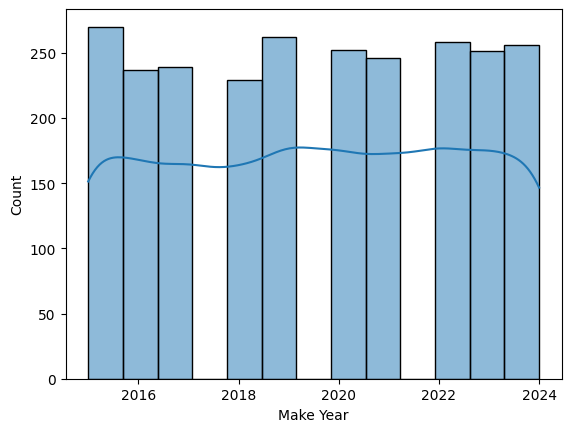

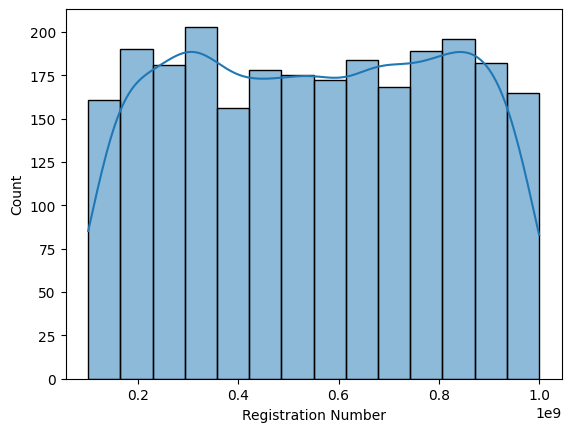

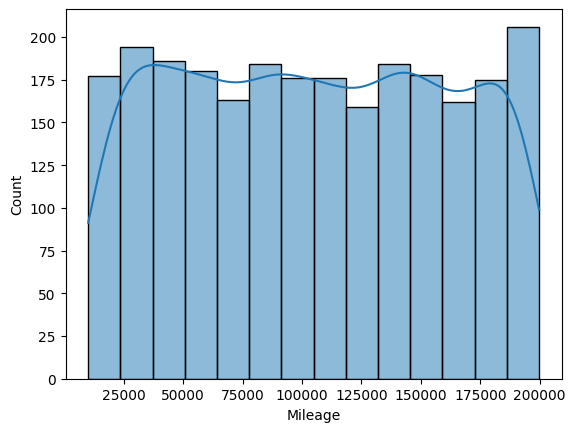

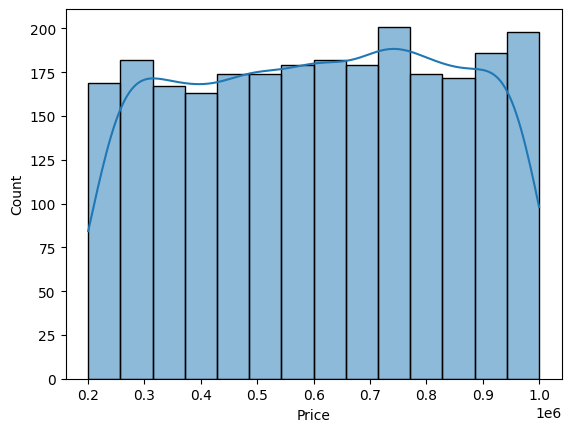

In [148]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(data[col], kde = True)
    plt.show()

In [149]:
data.isnull().sum()/ len(data) * 100

Company Name                 0.00
Car Name                     0.00
Variant                     10.48
Fuel Type                    0.00
Tyre Condition               0.00
Make Year                    0.00
Owner Type                   0.00
Registration Number          0.00
Mileage                      0.00
Price                        0.00
Transmission Type            0.00
Body Color                   0.00
Service Record               0.00
Insurance                    0.00
Registration Certificate     0.00
Accessories                 19.28
dtype: float64

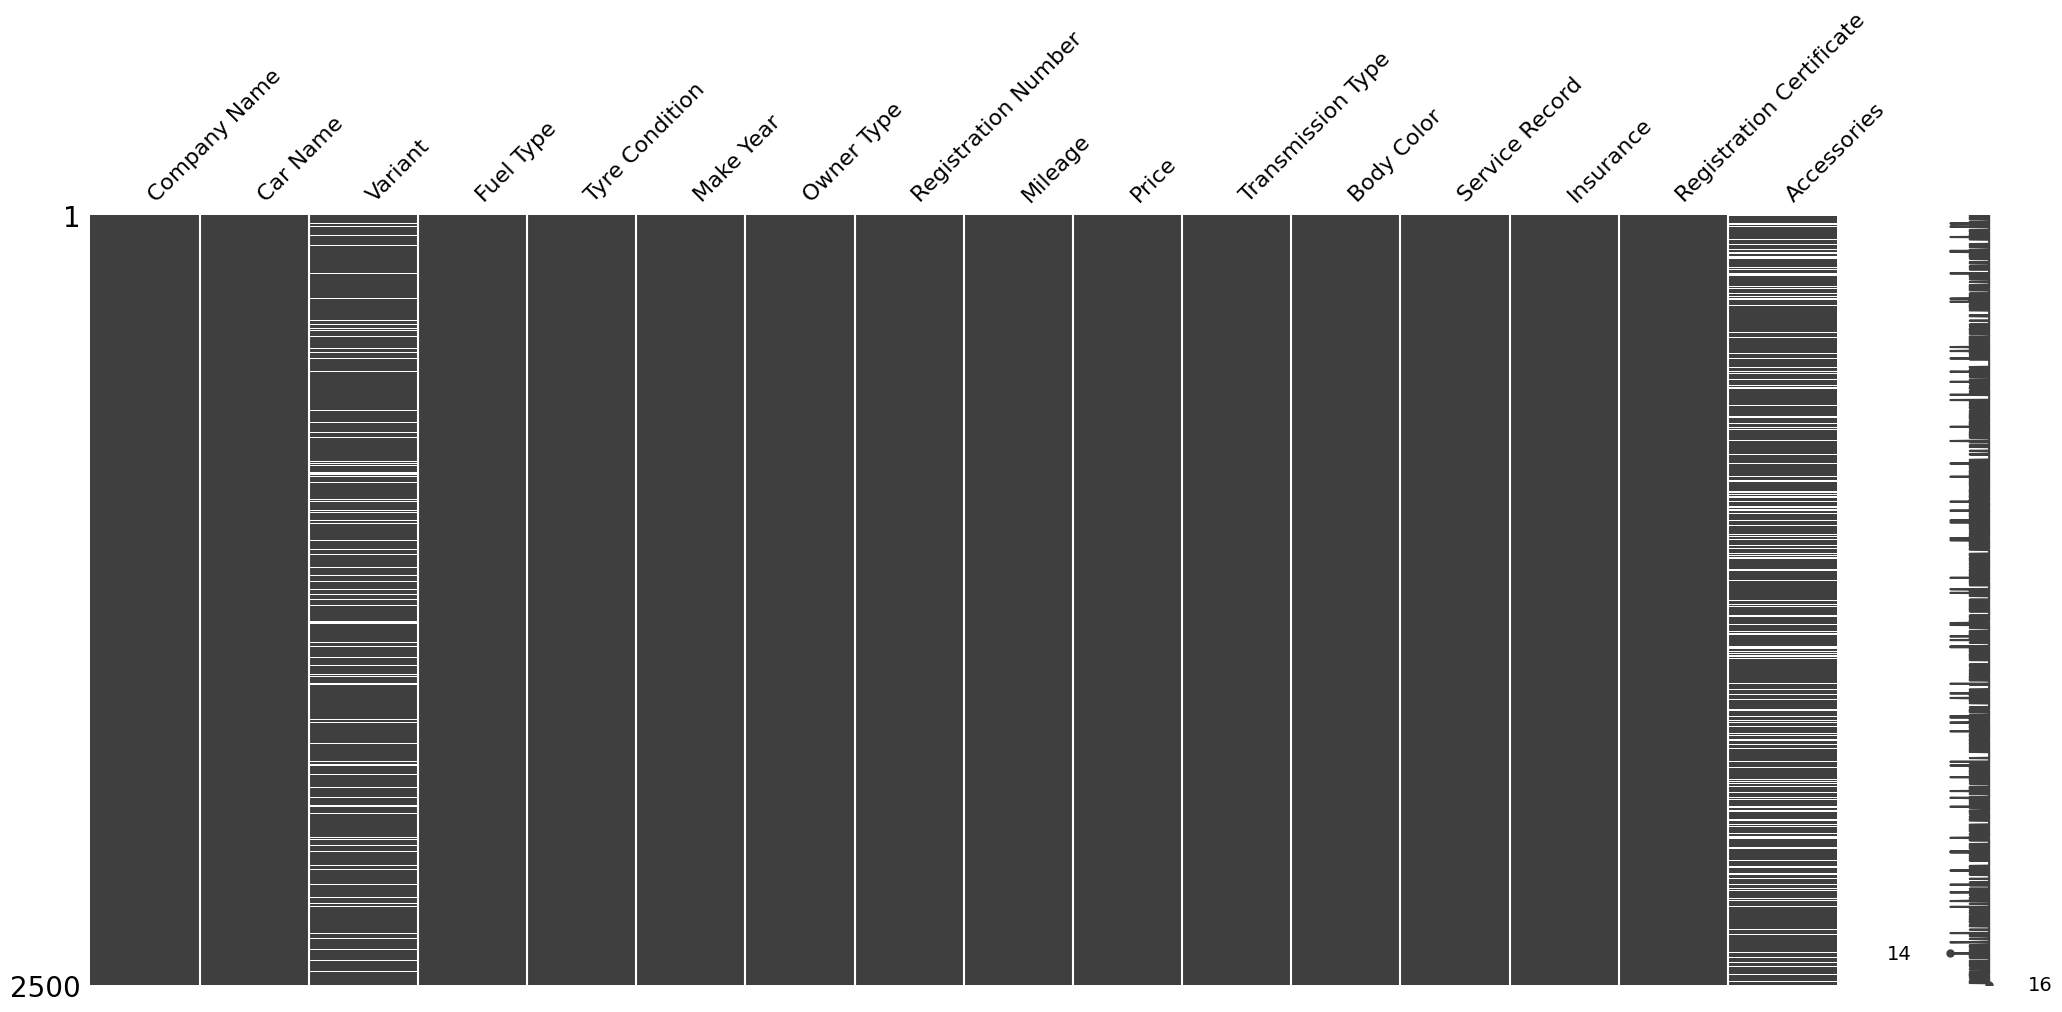

In [150]:
mnso.matrix(data)
plt.show()

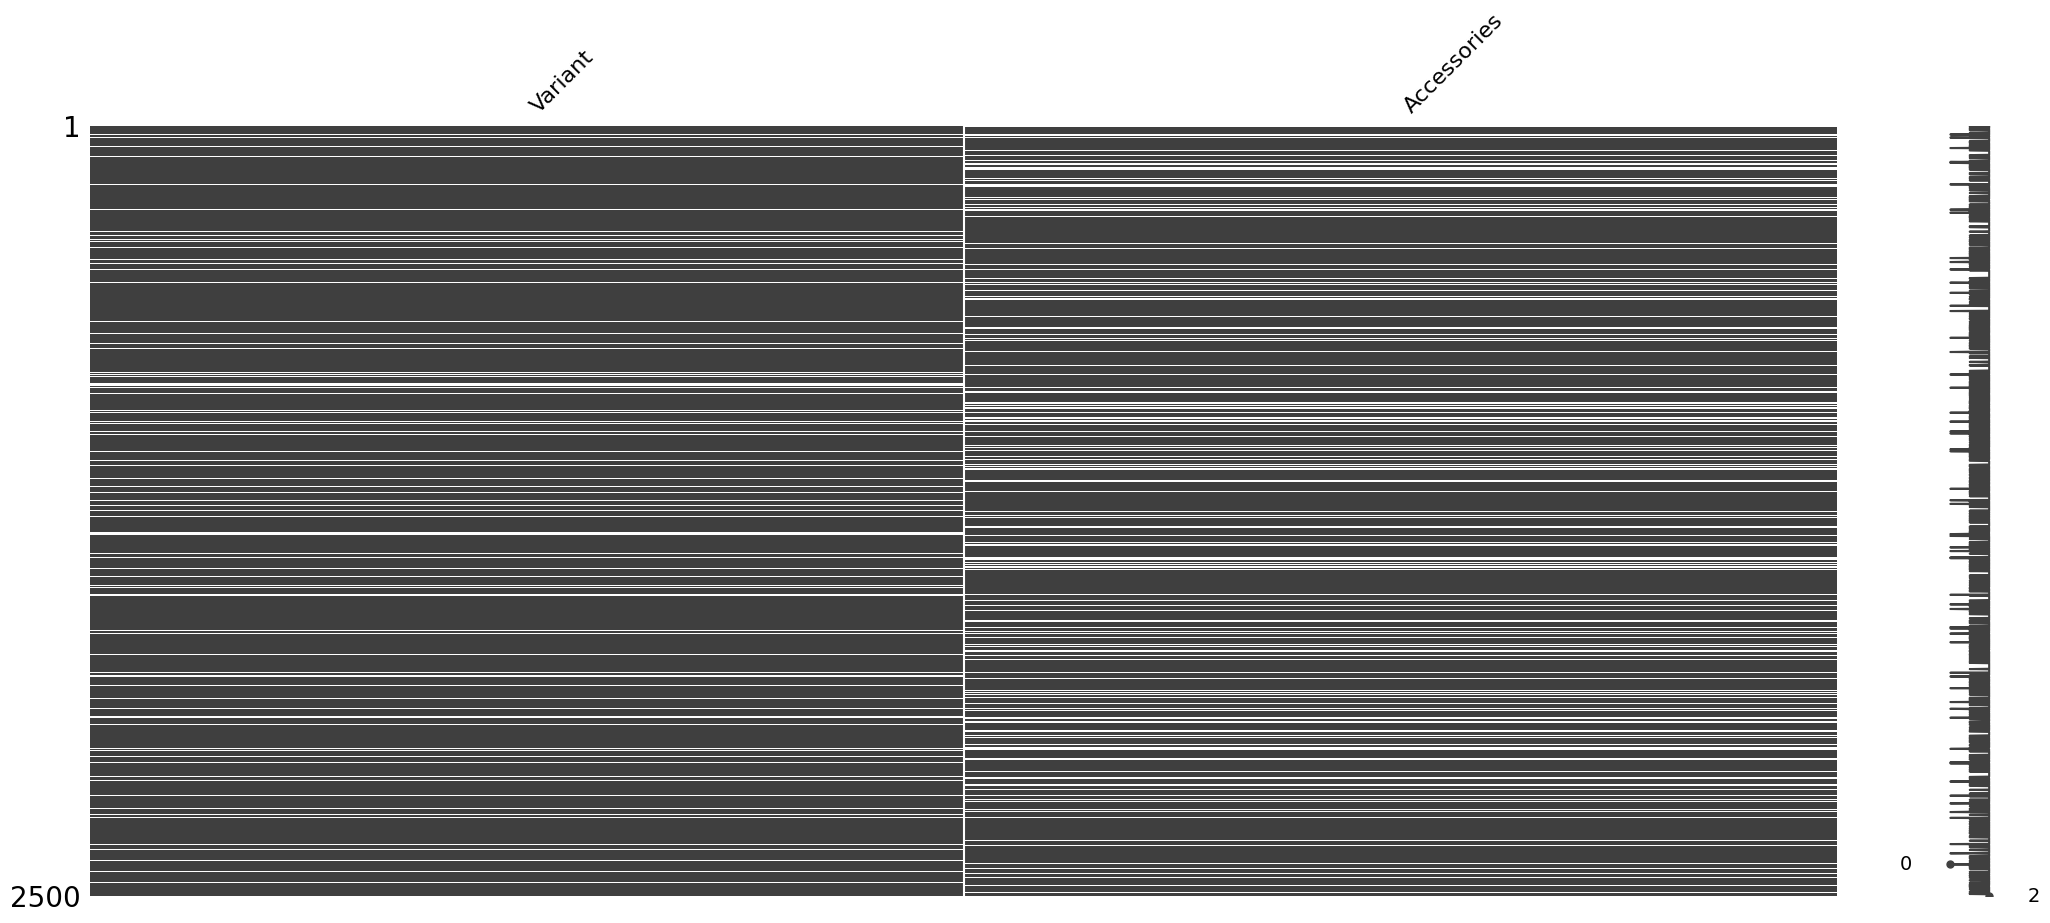

In [151]:
mnso.matrix(data[['Variant','Accessories']])
plt.show()

In [152]:
data['Variant'] = data['Variant'].fillna(data['Variant'].mode()[0])
data['Accessories'] = data['Accessories'].fillna(data['Accessories'].mode()[0])

In [153]:
data.isnull().sum()

Company Name                0
Car Name                    0
Variant                     0
Fuel Type                   0
Tyre Condition              0
Make Year                   0
Owner Type                  0
Registration Number         0
Mileage                     0
Price                       0
Transmission Type           0
Body Color                  0
Service Record              0
Insurance                   0
Registration Certificate    0
Accessories                 0
dtype: int64

In [154]:
data['Car Age'] = 2026 - data['Make Year']

In [155]:
data['Price Per Mile'] = data['Price'] / data['Mileage']

In [156]:
data.head()

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories,Car Age,Price Per Mile
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,844365584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels",8,14.377571
1,Kia,Seltos,RXE,Petrol,New,2020,Third,791143166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,Sunroof,6,11.634364
2,Kia,Accord,RXE,Petrol,New,2022,Second,413583344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,Sunroof,4,6.672219
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,927081763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels",2,6.865880
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,761545485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System",8,8.304536


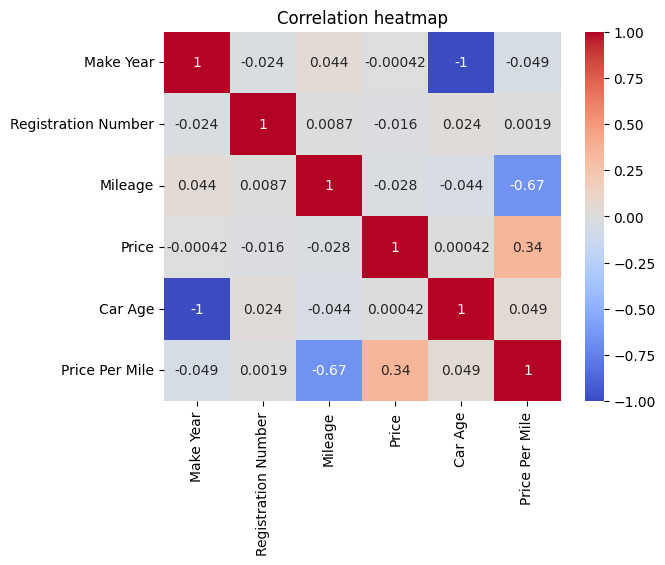

In [157]:
sns.heatmap(data.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title('Correlation heatmap')
plt.show()

In [158]:
data = data.drop(columns=['Registration Number','Make Year','Price'])

In [159]:
nominal_cols = ['Company Name', 'Car Name', 'Variant', 'Fuel Type', 'Body Color', 'Transmission Type']
data = pd.get_dummies(data, columns=nominal_cols, drop_first=True, dtype = int)

In [160]:
tyre_mapping = {'Needs Replacement': 0, 'Used': 1, 'New': 2}
owner_mapping = {'First': 1, 'Second': 2, 'Third': 3}

data['Tyre Condition'] = data['Tyre Condition'].map(tyre_mapping)
data['Owner Type'] = data['Owner Type'].map(owner_mapping)

In [161]:
data['Registration Certificate'] = data['Registration Certificate'].map({'Not Available': 0, 'Available': 1})
data['Insurance'] = data['Insurance'].map({'No Current Insurance': 0, 'Valid Until [date]': 1})

In [162]:
#low_cardinal = ['Fuel Type', 'Tyre Condition', 'Owner Type', 'Transmission Type','Insurance',
#            'Registration Certificate'] 
#medium_cardinal = ['Company Name','Car Name','Variant','Body Color']
#data = pd.get_dummies(data, columns=low_cardinal, drop_first=True, dtype = int)
#data = pd.get_dummies(data, columns=medium_cardinal, drop_first=True, dtype = int)

In [163]:
encoder = TargetEncoder(cols=['Service Record','Accessories'])
data[['Service Record', 'Accessories']] = encoder.fit_transform(data[['Service Record','Accessories']], data['Price Per Mile'])

In [164]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 46 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Tyre Condition                           2500 non-null   int64  
 1   Owner Type                               2500 non-null   int64  
 2   Mileage                                  2500 non-null   int64  
 3   Service Record                           2500 non-null   float64
 4   Insurance                                2500 non-null   int64  
 5   Registration Certificate                 2500 non-null   int64  
 6   Accessories                              2500 non-null   float64
 7   Car Age                                  2500 non-null   int64  
 8   Price Per Mile                           2500 non-null   float64
 9   Company Name_Ford                        2500 non-null   int64  
 10  Company Name_Honda                       2500 non-null   in

In [165]:
cat_cols = numeric_cols = data.select_dtypes(include = ['str']).columns
cat_cols

Index([], dtype='str')

In [166]:
data_1 = data.drop(columns = 'Price Per Mile').copy()

In [167]:
data_2 = data_1.copy()

In [168]:
std_scaler = StandardScaler()
data_1 = std_scaler.fit_transform(data_1)

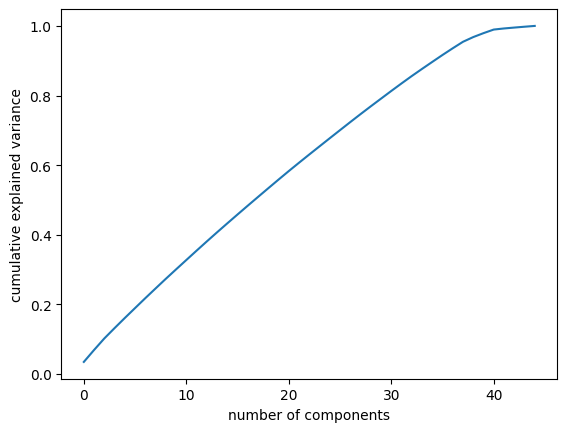

In [169]:
pca = PCA().fit(data_1)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

In [180]:
pca = PCA(n_components=37)
pca.fit(data_2)
X_pca = pca.transform(data_2)
print("original shape:   ", data_2.shape)
print("transformed shape:", X_pca.shape)

original shape:    (2500, 45)
transformed shape: (2500, 37)


In [181]:
y = data['Price Per Mile']

In [182]:
X_train, X_test,y_train,y_test = train_test_split(X_pca,y,test_size = 0.2, random_state= 42)

In [183]:
X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)

In [184]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [175]:
train_preds = lr_model.predict(X_train)
test_preds = lr_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds)}")

Training R2 score: 0.5524709123804376
Testing R2 score: 0.5338410257180414
Training MAE score: 4.6870295378176925
Testing MAE score: 4.790626206367072
Training MSE score: 54.74302562036782
Testing MSE score: 54.71293969451362
Training RMSE score: 7.3988529935637875
Testing RMSE score: 7.396819566172587


In [197]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth = 3)

In [198]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [199]:
train_preds_rf = rf_model.predict(X_train)
test_preds_rf = rf_model.predict(X_test)

print(f"Training R2 score: {r2_score(y_train, train_preds_rf)}")
print(f"Testing R2 score: {r2_score(y_test, test_preds_rf)}")

print(f"Training MAE score: {mean_absolute_error(y_train, train_preds_rf)}")
print(f"Testing MAE score: {mean_absolute_error(y_test, test_preds_rf)}")

print(f"Training MSE score: {mean_squared_error(y_train, train_preds_rf)}")
print(f"Testing MSE score: {mean_squared_error(y_test, test_preds_rf)}")

print(f"Training RMSE score: {root_mean_squared_error(y_train, train_preds_rf)}")
print(f"Testing RMSE score: {root_mean_squared_error(y_test, test_preds_rf)}")

Training R2 score: 0.825642438087683
Testing R2 score: 0.7817291645987322
Training MAE score: 2.993585646861232
Testing MAE score: 3.1674961146630656
Training MSE score: 21.327910839584963
Testing MSE score: 25.618382811948933
Training RMSE score: 4.618215114044057
Testing RMSE score: 5.061460541380218
